In [1]:
from __future__ import annotations
from constants import RunMode, ModelName
import gc
import os
import random
from dataclasses import dataclass, replace
from pathlib import Path
from time import perf_counter
from typing import Any, Literal, cast
import numpy as np
import torch
from torch import Tensor, nn, inference_mode
from data_index import build_indexed_dataset
from datasets import CarColorDataset, build_transforms
from evaluate import evaluate_model, print_eval_metrics
from io_utils import ensure_dir, load_checkpoint, save_json
from models.factory import build_model_with_overrides
from plots import (
    plot_class_distribution,
    plot_confusion_matrix,
    plot_training_curves,
)
from train import create_loader, train_model
from my_types import CheckpointPaths, IndexedDataset, SplitIndices, TrainingHistory, TrainHyperParams

os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")


SMOKE_MODE: bool = False
PROJECT_ROOT: Path = Path.cwd().parent
SRC_ROOT: Path = PROJECT_ROOT
DATASET_DIR: Path = PROJECT_ROOT / "dataset"
ARTIFACTS_DIR: Path = PROJECT_ROOT / ("artifacts_smoke" if SMOKE_MODE else "artifacts")
CHECKPOINTS_DIR: Path = ARTIFACTS_DIR / "checkpoints"
HISTORY_DIR: Path = ARTIFACTS_DIR / "history"
PLOTS_DIR: Path = ARTIFACTS_DIR / "plots"
REPORTS_DIR: Path = ARTIFACTS_DIR / "reports"
MODEL_NAMES: tuple[ModelName, ModelName, ModelName] = (
    "resnet18_scratch",
    "resnet18_pretrain",
    "resnet50_pretrain",
)
MODELS_CHECKPOINTS: dict[ModelName, Path] = {model_name: CHECKPOINTS_DIR / Path(f"{model_name}.pt") for model_name in MODEL_NAMES}
MODELS_HISTORIES: dict[ModelName, Path] = {model_name: HISTORY_DIR / Path(f"{model_name}_history.json") for model_name in MODEL_NAMES}
MODELS_PLOTS: dict[ModelName, Path] = {model_name: PLOTS_DIR / Path(f"{model_name}_curves.png") for model_name in MODEL_NAMES}
MODELS_METRICS: dict[ModelName, Path] = {model_name: REPORTS_DIR / Path(f"{model_name}_metrics.json") for model_name in MODEL_NAMES}
MODELS_CONFUSION_MATRICES: dict[ModelName, Path] = {model_name: PLOTS_DIR / Path(f"{model_name}_confusion_matrix.png") for model_name in MODEL_NAMES}
SKIP_TRAIN: bool = False
MIN_CLASS_COUNT: int = 400
EXCLUDED_CLASSES: set[str] = {"Unlisted"}
SPLIT_RATIOS: tuple[float, float, float] = (0.7, 0.15, 0.15)
SEED: int = 42
IMG_SIZE: int = 224
TARGET_F1: float = 0.8
PRETRAIN_FREEZE_STAGES: dict[ModelName, int] = {
    "resnet18_scratch": 0,
    "resnet18_pretrain": 2,
    "resnet50_pretrain": 5,
}
MODEL_TRAIN_BATCH_SIZE: dict[ModelName, int] = {
    "resnet18_scratch": 64 * 9,
    "resnet18_pretrain": 64 * 9,
    "resnet50_pretrain": 64 * 6,
}
MODEL_EVAL_BATCH_SIZE: dict[ModelName, int] = dict(MODEL_TRAIN_BATCH_SIZE)
MODEL_TRAIN_NUM_WORKERS: dict[ModelName, int] = {
    "resnet18_scratch": 4,
    "resnet18_pretrain": 4,
    "resnet50_pretrain": 4,
}
MODEL_EVAL_NUM_WORKERS: dict[ModelName, int] = dict(MODEL_TRAIN_NUM_WORKERS)
PERSISTENT_WORKERS: bool = True
SMOKE_MAX_SAMPLES_PER_CLASS_PER_SPLIT: int = 4
MODEL_HPARAMS: dict[ModelName, TrainHyperParams] = {
    "resnet18_scratch": TrainHyperParams(
        epochs=30 if not SMOKE_MODE else 2,
        learning_rate=1e-3,
        weight_decay=1e-4,
        patience=4,
    ),
    "resnet18_pretrain": TrainHyperParams(
        epochs=25 if not SMOKE_MODE else 2,
        learning_rate=3e-4,
        weight_decay=1e-4,
        patience=3,
    ),
    "resnet50_pretrain": TrainHyperParams(
        epochs=25 if not SMOKE_MODE else 2,
        learning_rate=2e-4,
        weight_decay=1e-4,
        patience=3,
    ),
}


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def resolve_device() -> torch.device:
    if torch.cuda.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cuda.matmul.allow_tf32 = False
        torch.backends.cudnn.allow_tf32 = False
        return torch.device("cuda")
    return torch.device("cpu")


def count_parameters(model: nn.Module) -> tuple[int, int]:
    total: int = sum(parameter.numel() for parameter in model.parameters())
    trainable: int = sum(
        parameter.numel() for parameter in model.parameters() if parameter.requires_grad
    )
    return trainable, total


def save_metadata(indexed: IndexedDataset) -> None:
    payload: dict[str, Any] = {
        "class_to_idx": indexed.class_to_idx,
        "split_sizes": {
            "train": len(indexed.splits.train),
            "val": len(indexed.splits.val),
            "test": len(indexed.splits.test),
        },
        "num_classes": len(indexed.idx_to_class),
        "num_samples": len(indexed.samples),
    }
    save_json(ARTIFACTS_DIR / "metadata" / "dataset_summary.json", payload)


def cleanup_cuda(device: torch.device) -> None:
    gc.collect()
    if device.type == "cuda":
        torch.cuda.empty_cache()


set_seed(SEED)

ensure_dir(ARTIFACTS_DIR)
ensure_dir(ARTIFACTS_DIR / "plots")
ensure_dir(ARTIFACTS_DIR / "history")
ensure_dir(ARTIFACTS_DIR / "checkpoints")
ensure_dir(ARTIFACTS_DIR / "reports")
ensure_dir(ARTIFACTS_DIR / "metadata")

device: torch.device = resolve_device()

print(f"PROJECT_ROOT={PROJECT_ROOT}")
print(f"DATASET_DIR={DATASET_DIR}")
print(f"ARTIFACTS_DIR={ARTIFACTS_DIR}")
print(f"Using device: {device}")
print(f"SMOKE_MODE={SMOKE_MODE}")

C:\Users\balbe\PycharmProjects\PythonCVLab1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PROJECT_ROOT=C:\Users\balbe\PycharmProjects\PythonCVLab1
DATASET_DIR=C:\Users\balbe\PycharmProjects\PythonCVLab1\dataset
ARTIFACTS_DIR=C:\Users\balbe\PycharmProjects\PythonCVLab1\artifacts
Using device: cuda
SMOKE_MODE=False


## Dataset preparation


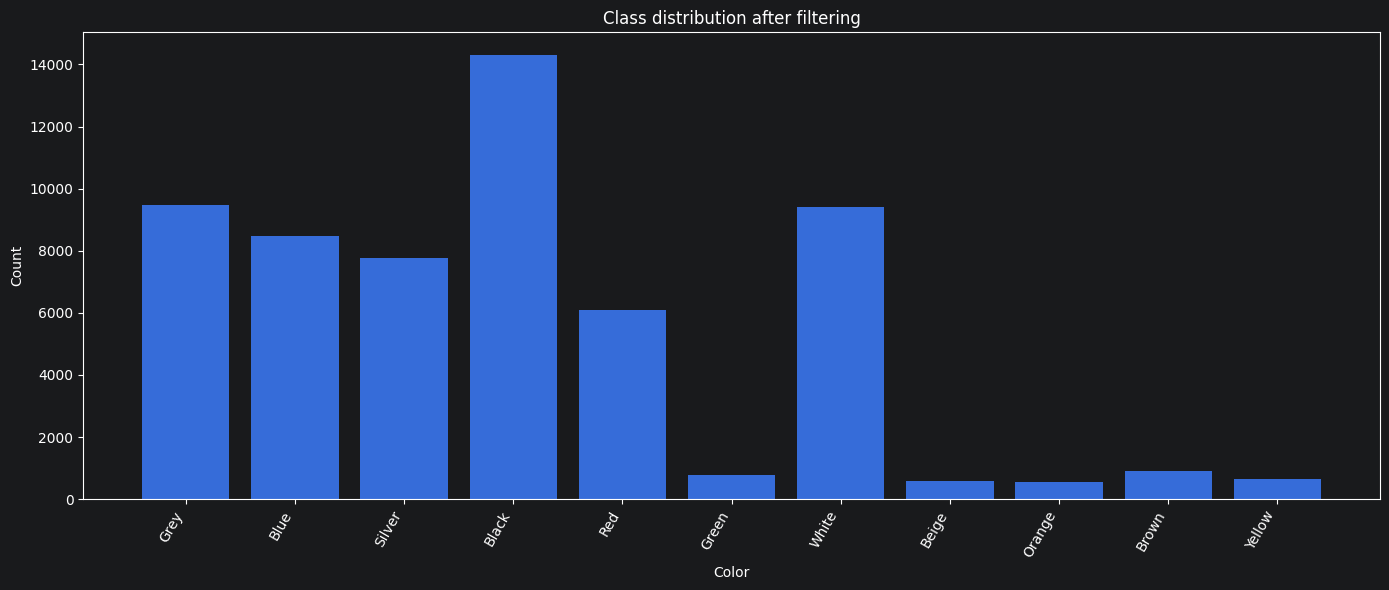

Split sizes:
len(indexed.splits.train) = 41333
len(indexed.splits.val) = 8857
len(indexed.splits.test) = 8858
len(indexed.idx_to_class) = 11
Grey: 9474
Blue: 8483
Silver: 7770
Black: 14317
Red: 6095
Green: 777
White: 9395
Beige: 600
Orange: 559
Brown: 911
Yellow: 667


In [2]:
indexed: IndexedDataset = build_indexed_dataset(
    dataset_dir=DATASET_DIR,
    min_class_count=MIN_CLASS_COUNT,
    split_ratios=SPLIT_RATIOS,
    seed=SEED,
    excluded_classes=EXCLUDED_CLASSES,
)

plot_class_distribution(
    class_counts=indexed.class_counts,
    output_path=ARTIFACTS_DIR / "plots" / "class_distribution.png",
)
save_metadata(indexed)

train_transform, eval_transform = build_transforms(IMG_SIZE)

print("Split sizes:")
print(f"{len(indexed.splits.train) = }")
print(f"{len(indexed.splits.val) = }")
print(f"{len(indexed.splits.test) = }")
print(f"{len(indexed.idx_to_class) = }")
print("\n".join(f"{key}: {value}" for key, value in indexed.class_counts.items()))


## Train


C:\Users\balbe\PycharmProjects\PythonCVLab1\.venv\Lib\site-packages\torch\nn\modules\module.py:1370: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:39.)
  return t.to(



===== resnet18_scratch =====
[resnet18_scratch] trainable_params=11,182,155 / total_params=11,182,155


[resnet18_scratch] epoch=1/30 train_loss=1.5058 val_loss=1.5348 val_f1=0.4993 lr=9.97e-04 epoch_time_sec=64.69 train_epoch_sec=49.58 val_epoch_sec=15.11


[resnet18_scratch] epoch=2/30 train_loss=1.2076 val_loss=1.3067 val_f1=0.6276 lr=9.89e-04 epoch_time_sec=49.16 train_epoch_sec=41.47 val_epoch_sec=7.69


[resnet18_scratch] epoch=3/30 train_loss=1.1020 val_loss=1.1520 val_f1=0.6928 lr=9.76e-04 epoch_time_sec=48.29 train_epoch_sec=40.24 val_epoch_sec=8.04


...

[resnet50_pretrain] epoch=5/25 train_loss=0.6878 val_loss=0.8054 val_f1=0.8665 lr=1.81e-04 epoch_time_sec=55.08 train_epoch_sec=44.99 val_epoch_sec=10.09


[resnet50_pretrain] epoch=6/25 train_loss=0.6534 val_loss=0.8277 val_f1=0.8463 lr=1.73e-04 epoch_time_sec=54.81 train_epoch_sec=45.15 val_epoch_sec=9.66


[resnet50_pretrain] epoch=7/25 train_loss=0.6304 val_loss=0.8129 val_f1=0.8608 lr=1.64e-04 epoch_time_sec=54.82 train_epoch_sec=45.05 val_epoch_sec=9.77


C:\Users\balbe\PycharmProjects\PythonCVLab1\src\plots.py:54: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


[resnet50_pretrain] epoch=8/25 train_loss=0.6142 val_loss=0.8137 val_f1=0.8640 lr=1.54e-04 epoch_time_sec=55.13 train_epoch_sec=45.52 val_epoch_sec=9.61
[resnet50_pretrain] early stopping at epoch 8


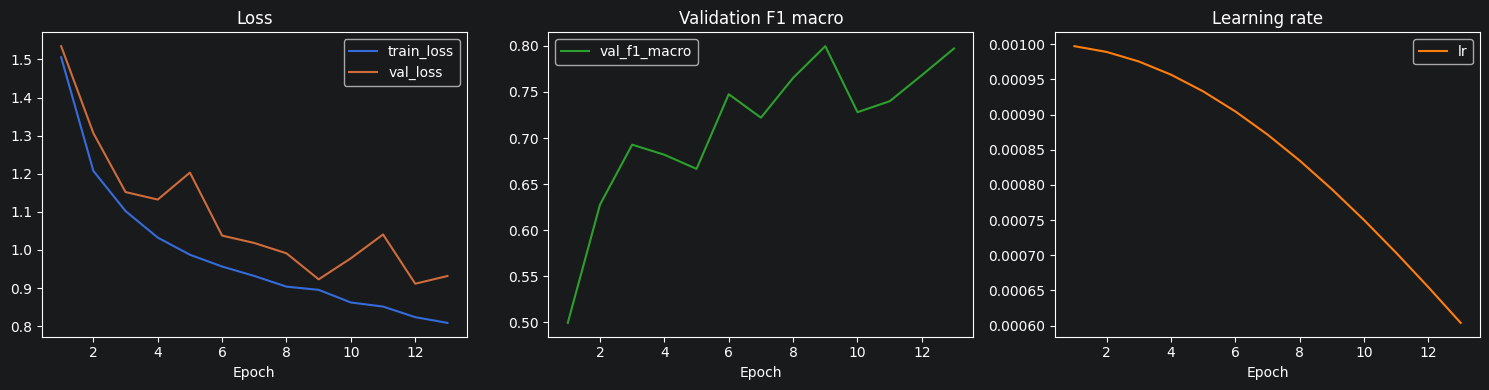

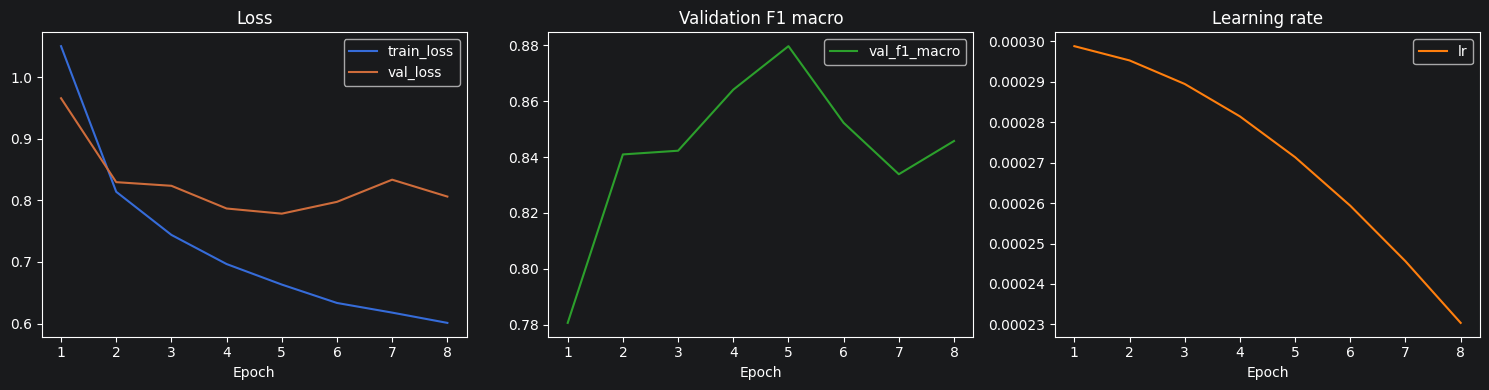

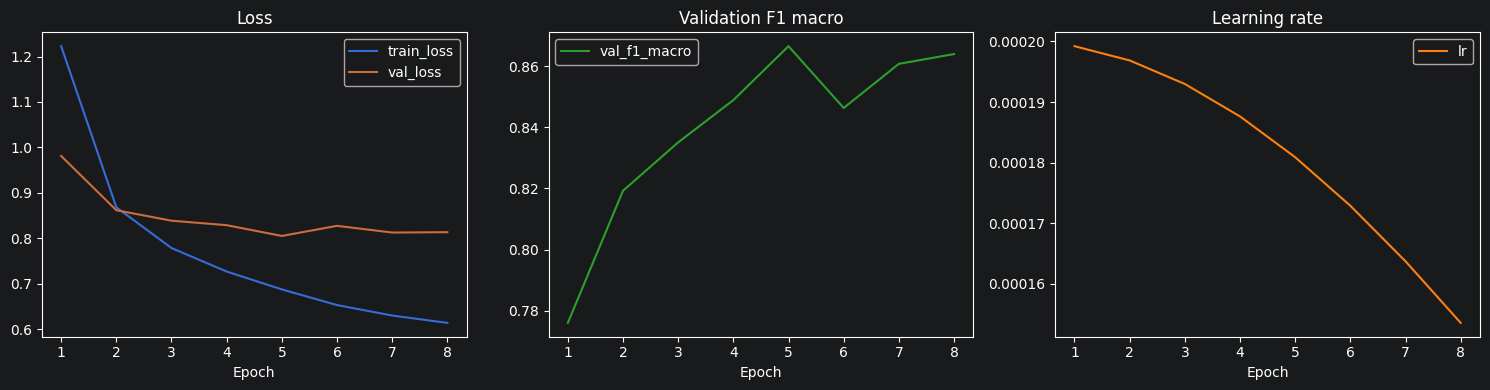

In [3]:
def train_step():
    for model_name in MODEL_NAMES:
        print(f"\n===== {model_name} =====")
        train_batch_size: int = MODEL_TRAIN_BATCH_SIZE[model_name]
        eval_batch_size: int = MODEL_EVAL_BATCH_SIZE[model_name]
        train_num_workers: int = MODEL_TRAIN_NUM_WORKERS[model_name]
        eval_num_workers: int = MODEL_EVAL_NUM_WORKERS[model_name]

        model_train: nn.Module = build_model_with_overrides(
            model_name=model_name,
            num_classes=len(indexed.idx_to_class),
            pretrain_freeze_stages=PRETRAIN_FREEZE_STAGES,
        )
        trainable_params, total_params = count_parameters(model_train)
        print(
            f"[{model_name}] trainable_params={trainable_params:,} / total_params={total_params:,}"
        )

        train_dataset = CarColorDataset(
            samples=indexed.samples,
            targets=indexed.targets,
            indices=indexed.splits.train,
            transform=train_transform,
        )
        val_dataset = CarColorDataset(
            samples=indexed.samples,
            targets=indexed.targets,
            indices=indexed.splits.val,
            transform=eval_transform,
        )

        train_loader = create_loader(
            dataset=train_dataset,
            batch_size=train_batch_size,
            num_workers=train_num_workers,
            shuffle=True,
            persistent_workers=PERSISTENT_WORKERS,
        )
        val_loader = create_loader(
            dataset=val_dataset,
            batch_size=eval_batch_size,
            num_workers=eval_num_workers,
            shuffle=False,
            persistent_workers=PERSISTENT_WORKERS,
        )

        train_targets_split: list[int] = [indexed.targets[i] for i in indexed.splits.train]
        history: TrainingHistory = train_model(
            model=model_train,
            model_name=model_name,
            train_loader=train_loader,
            val_loader=val_loader,
            train_targets=train_targets_split,
            num_classes=len(indexed.idx_to_class),
            hparams=MODEL_HPARAMS[model_name],
            device=device,
            class_to_idx=indexed.class_to_idx,
            checkpoint_path=MODELS_CHECKPOINTS[model_name],
            history_path=MODELS_HISTORIES[model_name],
        )

        plot_training_curves(history=history, output_path=MODELS_PLOTS[model_name])

        # del model_train
        # del train_loader
        # del val_loader
        # cleanup_cuda(device)


if not SKIP_TRAIN:
    train_step()


## Evaluation



===== resnet18_scratch evaluation =====


C:\Users\balbe\PycharmProjects\PythonCVLab1\src\plots.py:72: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


[resnet18_scratch] test_sec=17.44

Model: resnet18_scratch
F1_macro: 0.8065
F1 per class:
           Beige: 0.6528
           Black: 0.9023
            Blue: 0.8621
           Brown: 0.6690
           Green: 0.6588
            Grey: 0.7757
          Orange: 0.6753
             Red: 0.9642
          Silver: 0.8199
           White: 0.9363
          Yellow: 0.9548

===== resnet18_pretrain evaluation =====


C:\Users\balbe\PycharmProjects\PythonCVLab1\src\plots.py:72: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


[resnet18_pretrain] test_sec=17.97

Model: resnet18_pretrain
F1_macro: 0.8794
F1 per class:
           Beige: 0.8478
           Black: 0.9411
            Blue: 0.9135
           Brown: 0.7531
           Green: 0.8052
            Grey: 0.8599
          Orange: 0.7651
             Red: 0.9767
          Silver: 0.8856
           White: 0.9721
          Yellow: 0.9538

===== resnet50_pretrain evaluation =====


C:\Users\balbe\PycharmProjects\PythonCVLab1\src\plots.py:72: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


[resnet50_pretrain] test_sec=20.48

Model: resnet50_pretrain
F1_macro: 0.8663
F1 per class:
           Beige: 0.7869
           Black: 0.9158
            Blue: 0.8815
           Brown: 0.7422
           Green: 0.7733
            Grey: 0.8255
          Orange: 0.8025
             Red: 0.9803
          Silver: 0.8914
           White: 0.9704
          Yellow: 0.9600


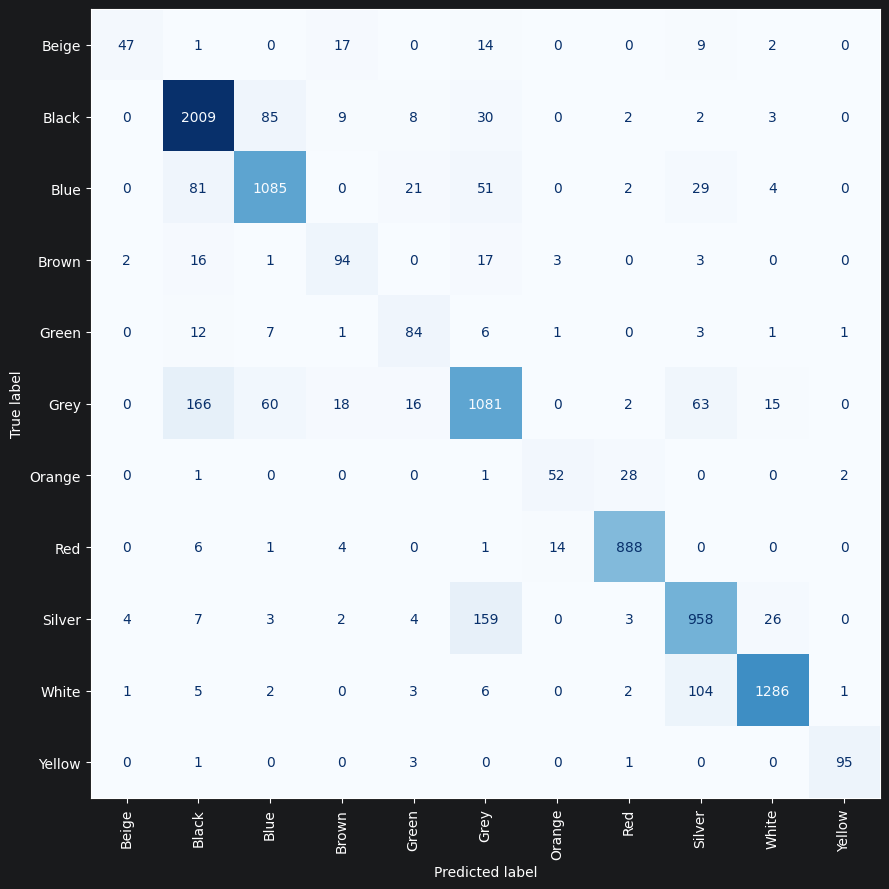

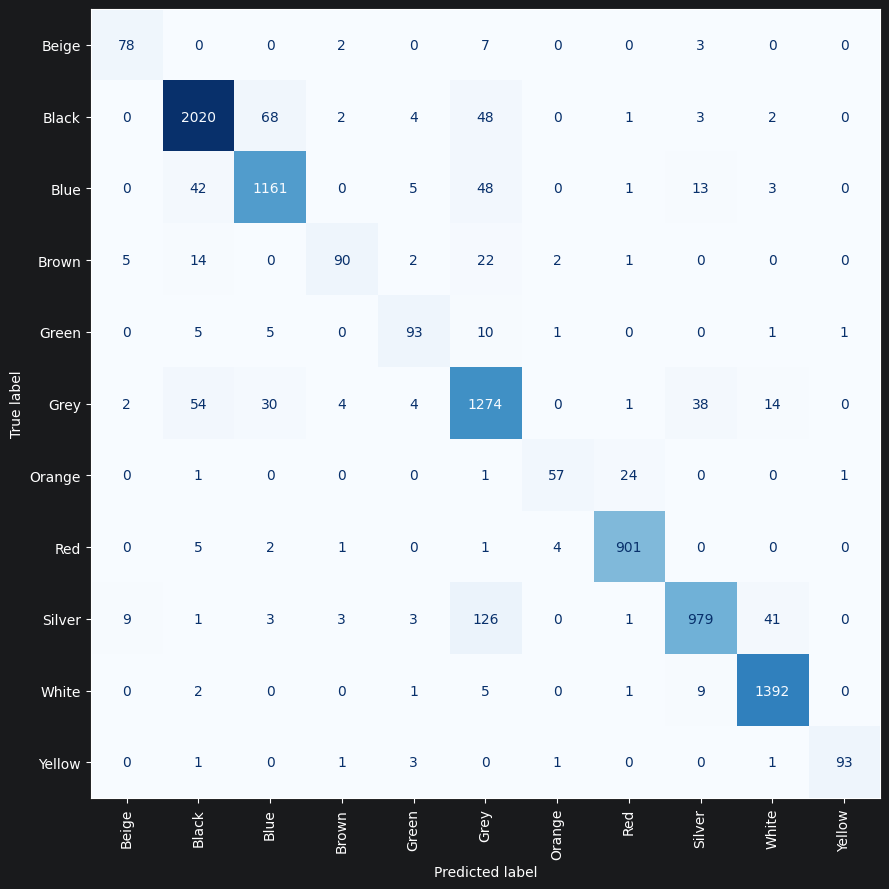

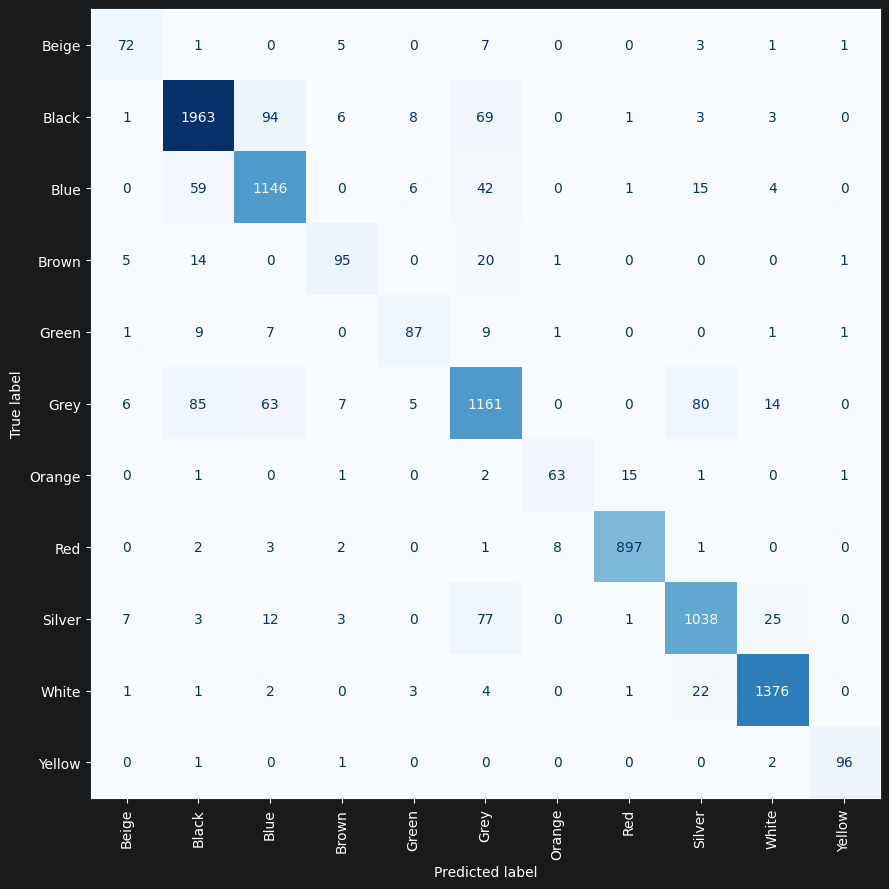

In [4]:
@inference_mode()
def eval_step():
    for model_name in MODEL_NAMES:
        print(f"\n===== {model_name} evaluation =====")
        if not MODELS_CHECKPOINTS[model_name].exists():
            raise FileNotFoundError(
                f"Checkpoint for {model_name} not found: {MODELS_CHECKPOINTS[model_name]}. "
                "Run the Train section first."
            )

        eval_batch_size: int = MODEL_EVAL_BATCH_SIZE[model_name]
        eval_num_workers: int = MODEL_EVAL_NUM_WORKERS[model_name]

        model_eval: nn.Module = build_model_with_overrides(
            model_name=model_name,
            num_classes=len(indexed.idx_to_class),
            pretrain_freeze_stages=PRETRAIN_FREEZE_STAGES,
        )
        checkpoint: dict[str, Any] = load_checkpoint(MODELS_CHECKPOINTS[model_name], device=device)
        model_state_any: Any = checkpoint.get("model_state_dict")
        assert isinstance(model_state_any, dict), \
            f"Checkpoint {MODELS_CHECKPOINTS[model_name]} does not contain model_state_dict"

        model_eval.load_state_dict(model_state_any)
        model_eval.to(device)

        test_dataset = CarColorDataset(
            samples=indexed.samples,
            targets=indexed.targets,
            indices=indexed.splits.test,
            transform=eval_transform,
        )
        test_loader = create_loader(
            dataset=test_dataset,
            batch_size=eval_batch_size,
            num_workers=eval_num_workers,
            shuffle=False,
            persistent_workers=PERSISTENT_WORKERS,
        )

        test_start_time: float = perf_counter()
        eval_artifacts = evaluate_model(
            model=model_eval,
            loader=test_loader,
            device=device,
            idx_to_class=indexed.idx_to_class,
            model_name=model_name,
        )
        test_elapsed: float = perf_counter() - test_start_time
        print(f"[{model_name}] test_sec={test_elapsed:.2f}")

        print_eval_metrics(eval_artifacts.metrics)
        save_json(
            MODELS_METRICS[model_name],
            {
                "model_name": eval_artifacts.metrics.model_name,
                "f1_macro": eval_artifacts.metrics.f1_macro,
                "f1_per_class": eval_artifacts.metrics.f1_per_class,
                "eval_batch_size": eval_batch_size,
            }
        )

        plot_confusion_matrix(
            y_true=eval_artifacts.y_true,
            y_pred=eval_artifacts.y_pred,
            labels=indexed.idx_to_class,
            output_path=MODELS_CONFUSION_MATRICES[model_name],
        )

        # del model_eval
        # del test_loader
        # cleanup_cuda(device)


eval_step()